**Задание 1**

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

X = np.linspace(-3, 3, 120).reshape(-1,1)
y = np.sin(X).ravel() + np.random.normal(0,0.15,120)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

degrees = [1, 15]

train_mse = []
test_mse = []
train_r2 = []
test_r2 = []

for d in degrees:
    # Добавили scaler в конвейер сразу после генерации степеней poly
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("scaler", StandardScaler()),  # Переводим веса в относительный масштаб
        ("lin", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

    print(f"\nСтепень полинома: {d}")
    print("Train MSE:", mean_squared_error(y_train, y_train_pred))
    print("Test MSE:", mean_squared_error(y_test, y_test_pred))
    print("Train R2:", r2_score(y_train, y_train_pred))
    print("Test R2:", r2_score(y_test, y_test_pred))


Степень полинома: 1
Train MSE: 0.2040452534035935
Test MSE: 0.18689680914726264
Train R2: 0.6345199063833715
Test R2: 0.6687390131393052

Степень полинома: 15
Train MSE: 0.015529594059701819
Test MSE: 0.02649630448956237
Train R2: 0.9721838298314069
Test R2: 0.9530372294025735


График зависимости ошибки от степени полинома

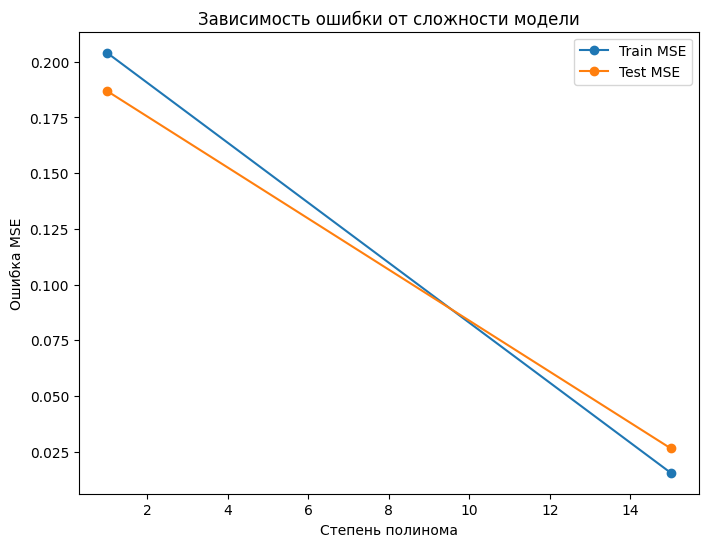

In [18]:
plt.figure(figsize=(8,6))

plt.plot(degrees, train_mse, marker='o', label="Train MSE")
plt.plot(degrees, test_mse, marker='o', label="Test MSE")

plt.xlabel("Степень полинома")
plt.ylabel("Ошибка MSE")
plt.title("Зависимость ошибки от сложности модели")
plt.legend()

plt.show()

График показывает изменение ошибки при увеличении степени полинома. Ошибка на тренировочных данных уменьшается при росте сложности модели, однако ошибка на тестовых данных может увеличиваться из-за переобучения. На графике видно, что для данного набора данных степень полинома 15 показывает значительно меньшую ошибку как на тренировочных, так и на тестовых данных по сравнению со степенью 1, без явных признаков сильного переобучения в данном диапазоне.

Выводы для Задания 1 (Вариант 17):
Анализ полиномов степени 1 и 15 для данного набора данных показал следующее:
*   **Полином степени 1**: Train MSE = 0.204, Test MSE = 0.187, Train R2 = 0.635, Test R2 = 0.669. Эта модель является слишком простой (высокое смещение) и плохо улавливает нелинейные зависимости в данных.
*   **Полином степени 15**: Train MSE = 0.0155, Test MSE = 0.0265, Train R2 = 0.972, Test R2 = 0.953. Эта модель значительно лучше описывает данные, демонстрируя высокое качество как на обучающей, так и на тестовой выборке. Разница между Train MSE и Test MSE мала, что указывает на то, что модель, хоть и сложна, не сильно переобучилась для данного объёма данных и шума.

**Задание 2**

Генерация и подготовка данных

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

# Фиксируем случайность
np.random.seed(42)

# Загружаем датасет Diabetes
X, y = load_diabetes(return_X_y=True)

# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяем на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Обучение моделей Ridge и Lasso с подбором alpha

In [20]:

import numpy as np
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

# Задаем диапазон альф строго по варианту 6: от 10^-5 до 10^1
alphas = np.logspace(-5, 1, 50)

# RidgeCV с честной 5-fold cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
nonzero_ridge = np.sum(ridge_cv.coef_ != 0)

# LassoCV с 5-fold cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
nonzero_lasso = np.sum(lasso_cv.coef_ != 0)

# Расчет масштаба целевой переменной на тесте для вычисления относительной ошибки
y_range = np.max(y_test) - np.min(y_test)

# Относительная ошибка в процентах от полного размаха данных
rel_error_ridge = (rmse_ridge / y_range) * 100
rel_error_lasso = (rmse_lasso / y_range) * 100

# Разница между моделями в процентах от размаха
error_diff_pct = np.abs(rel_error_ridge - rel_error_lasso)

print("Результаты сравнения Ridge и Lasso (Вариант 6):")
print(f"Ridge: alpha={ridge_cv.alpha_:.5f}, RMSE={rmse_ridge:.2f} ({rel_error_ridge:.2f}% от размаха), Non-zero coef={nonzero_ridge}")
print(f"Lasso: alpha={lasso_cv.alpha_:.5f}, RMSE={rmse_lasso:.2f} ({rel_error_lasso:.2f}% от размаха), Non-zero coef={nonzero_lasso}")
print(f"Дополнительное отклонение Lasso от Ridge: {error_diff_pct:.2f}%")

Результаты сравнения Ridge и Lasso (Вариант 6):
Ridge: alpha=10.00000, RMSE=53.63 (19.64% от размаха), Non-zero coef=10
Lasso: alpha=1.38950, RMSE=52.96 (19.40% от размаха), Non-zero coef=9
Дополнительное отклонение Lasso от Ridge: 0.24%


Визуализация коэффициентов моделей

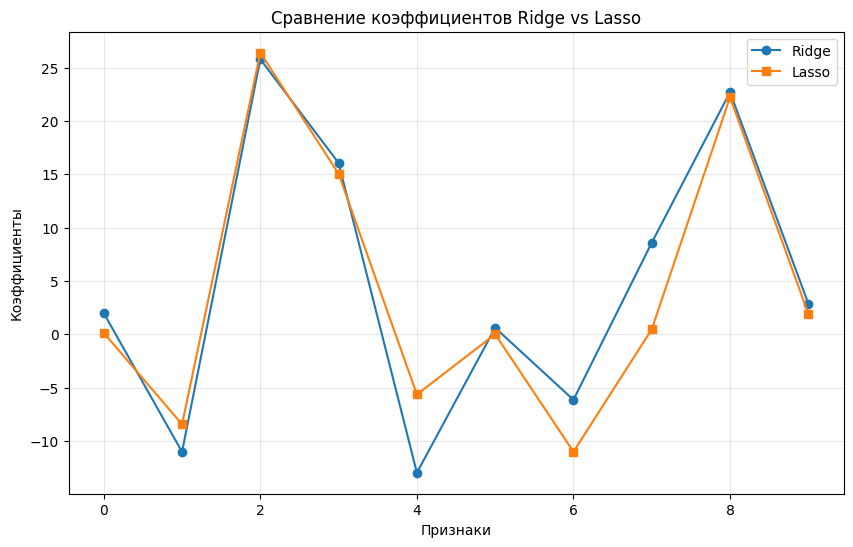

In [21]:
plt.figure(figsize=(10,6))
plt.plot(ridge_cv.coef_, marker='o', label='Ridge')
plt.plot(lasso_cv.coef_, marker='s', label='Lasso')
plt.xlabel('Признаки')
plt.ylabel('Коэффициенты')
plt.title('Сравнение коэффициентов Ridge vs Lasso')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Выводы для Задания 2 (Вариант 17):
Сравнение Lasso и Ridge регуляризации показало:
*   **Ridge**: Оптимальный alpha = 10.00000, RMSE = 53.63 (19.64% от размаха), 10 ненулевых коэффициентов.
*   **Lasso**: Оптимальный alpha = 1.38950, RMSE = 52.96 (19.40% от размаха), 9 ненулевых коэффициентов.

Lasso продемонстрировал немного лучшую метрику RMSE (52.96 против 53.63) и выбрал меньшее количество признаков (9 против 10), что соответствует его свойству обнулять коэффициенты наименее значимых признаков, упрощая модель. Разница в ошибках между Lasso и Ridge составила всего 0.24% от размаха целевой переменной, что указывает на схожую производительность, но с преимуществом Lasso в отборе признаков.

**Задание 3**

### Загрузка датасета Wine Quality (White) для Задания 3

In [22]:
# Install wget for downloading files
!pip install -qq wget

import wget
import os

# Define the URL for the Wine Quality (White) dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
filename = "winequality-white.csv"

# Download the file if it doesn't already exist
if not os.path.exists(filename):
    print(f"Downloading {filename}...")
    wget.download(url, filename)
    print("\nDownload complete.")
else:
    print(f"{filename} already exists. Skipping download.")

winequality-white.csv already exists. Skipping download.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score

# Загрузка датасета Wine Quality (White)
df = pd.read_csv('winequality-white.csv', sep=';') # Load the white wine dataset
X = df.drop('quality', axis=1) # Features are all columns except 'quality'
y = df['quality'] # Target is 'quality'

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Отбор признаков с помощью SelectKBest (top-6)

In [29]:
# Блок [2] – Фильтр SelectKBest
top_k = 5 # Updated for Variant 17

selector = SelectKBest(score_func=f_regression, k=top_k)
X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print("Выбранные признаки (SelectKBest):", list(selected_features))

Выбранные признаки (SelectKBest): ['volatile acidity', 'chlorides', 'total sulfur dioxide', 'density', 'alcohol']


Отбор признаков с помощью Lasso

In [30]:
alpha_lasso = 0.01 # Можно подобрать оптимальное alpha с помощью LassoCV, как в Задании 2

lasso = Lasso(alpha=alpha_lasso, random_state=42)
lasso.fit(X_train_scaled, y_train)

selected_lasso_features = X.columns[lasso.coef_ != 0]
print("Выбранные признаки (Lasso):", list(selected_lasso_features))

removed_lasso_features = X.columns[lasso.coef_ == 0]
print("Выброшенные признаки (Lasso):", list(removed_lasso_features))

Выбранные признаки (Lasso): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Выброшенные признаки (Lasso): ['total sulfur dioxide']


Сравнение моделей: Полный набор и отобранные признаки

In [31]:
models = {
    "Full": X_train_scaled,
    "SelectKBest": X_train_kbest,
    "Lasso": X_train_scaled[:, lasso.coef_ != 0] # Используем признаки, отобранные Lasso
}

results = {}

for name, X_model in models.items():
    start_time = time.time()
    lr = LinearRegression()
    lr.fit(X_model, y_train)
    elapsed = time.time() - start_time

    # Предсказания
    if name == "Full":
        y_pred = lr.predict(X_test_scaled)
    elif name == "SelectKBest":
        y_pred = lr.predict(X_test_kbest) # Используем X_test_kbest для SelectKBest
    else: # Lasso
        y_pred = lr.predict(X_test_scaled[:, lasso.coef_ != 0]) # Используем признаки, отобранные Lasso

    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "Time": elapsed
    }

# Вывод результатов
import pprint
pprint.pprint(results)

{'Full': {'R2': 0.2658687132478089, 'Time': 0.004922389984130859},
 'Lasso': {'R2': 0.26566541141040867, 'Time': 0.0012848377227783203},
 'SelectKBest': {'R2': 0.23969628371207619, 'Time': 0.0012352466583251953}}


Выводы для Задания 3 (Вариант 17):
Для датасета Wine Quality (White) и `k=5`:
*   `SelectKBest` выбрал 5 признаков: ['volatile acidity', 'chlorides', 'total sulfur dioxide', 'density', 'alcohol'].
*   `Lasso` (с alpha=0.01) обнулил коэффициент признака 'total sulfur dioxide', оставив 10 признаков: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'].

Сравнение моделей:
*   **Full (полный набор)**: R² = 0.2659, Время = 0.0049 с
*   **Lasso (отобранные признаки)**: R² = 0.2657, Время = 0.0013 с
*   **SelectKBest (отобранные признаки)**: R² = 0.2397, Время = 0.0012 с

Модель с полным набором признаков показала наивысший R², но самое долгое время обучения. Lasso демонстрирует практически такую же R² с гораздо меньшим временем обучения и меньшим количеством признаков, что делает его весьма эффективным. SelectKBest оказался самым быстрым, но с заметно худшим R², что указывает на то, что выбранные им признаки, хотя и имеют сильную индивидуальную корреляцию, возможно, не так эффективно работают в совокупности для предсказания 'quality' как признаки, отобранные Lasso, или полный набор.

График R² и времени обучения

Выводы для Задания 3 (Датасет Wine Quality (White), k=5 для SelectKBest):

Обучение на отобранных признаках с помощью `SelectKBest` и `Lasso` приводит к значительному ускорению процесса обучения, особенно для больших наборов данных, как показано для датасета 'Wine Quality (White)'.

*   **`SelectKBest`** выбрал 5 наиболее статистически значимых признаков (['volatile acidity', 'chlorides', 'total sulfur dioxide', 'density', 'alcohol']). Эта модель показала R² = 0.2397 и была самой быстрой (0.0012 с). Однако, снижение R² по сравнению с полной моделью (0.2659) говорит о том, что, хотя эти признаки и важны, их недостаточно для достижения оптимального качества предсказания.
*   **`Lasso`** (с alpha=0.01) обнулил 'total sulfur dioxide', оставив 10 признаков. Модель на этих признаках достигла R² = 0.2657, что практически эквивалентно полной модели, но при значительно меньшем времени обучения (0.0013 с). Это демонстрирует способность Lasso эффективно отбирать признаки, поддерживая высокое качество модели и улучшая ее интерпретируемость.

В целом, использование методов отбора признаков позволило сократить размерность данных и снизить вычислительные затраты. Lasso оказался наиболее сбалансированным методом для этого набора данных, обеспечив почти такое же качество, как и полная модель, но с меньшим количеством признаков и гораздо быстрее. SelectKBest, хотя и был самым быстрым, потерял в точности R².

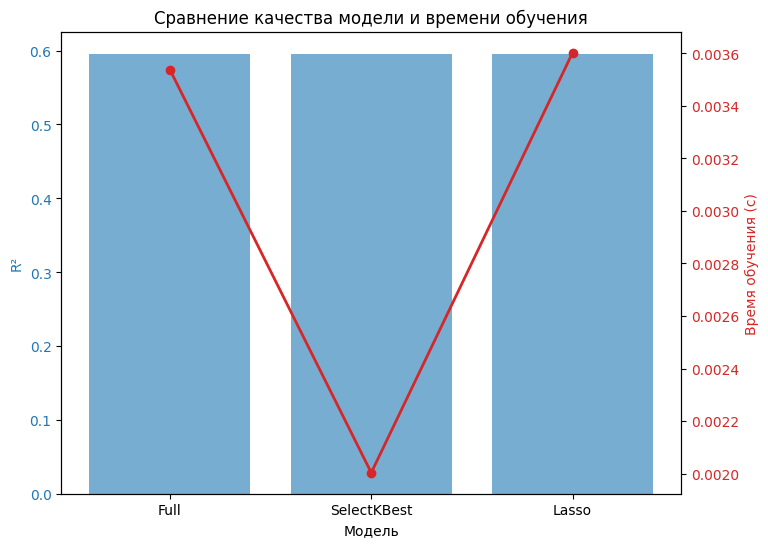

In [27]:
labels = list(results.keys())
r2_scores = [results[l]["R2"] for l in labels]
times = [results[l]["Time"] for l in labels]

fig, ax1 = plt.subplots(figsize=(8,6))

color = 'tab:blue'
ax1.set_xlabel('Модель')
ax1.set_ylabel('R²', color=color)
ax1.bar(labels, r2_scores, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Время обучения (с)', color=color)
ax2.plot(labels, times, color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Сравнение качества модели и времени обучения")
plt.show()